# *****Modeling a moving average process*****

### **A moving average process, or the moving average (MA) model, states that the current value is linearly dependent on the current and past error terms.The error terms are assumed to be mutually independent and normally distributed, just like white noise.**

### **A moving average model is denoted as MA(q), where q is the order. The model expresses the present value as a linear combination of the mean of the series μ, the present error term ϵt, and past error terms ϵt–q. The magnitude of the impact of past errors on the present value is quantified using a coefficient denoted as θq. Mathematically, we express a general moving average process of order q as in equation.**
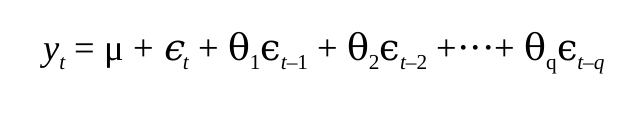

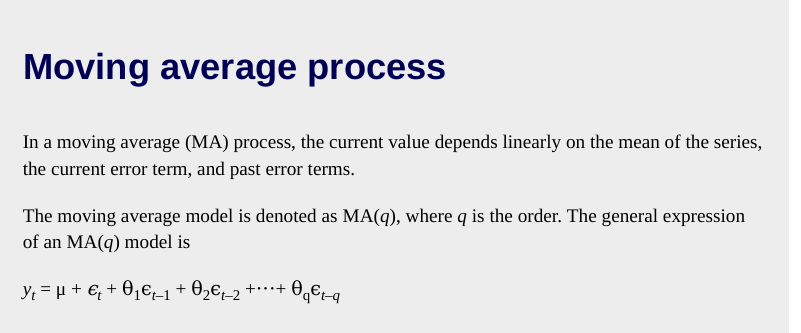

### ***we can see how the order q of the MA(q) process affects the number of past error terms that must be included in the model. The larger q is, the more past error terms affect the present value. Therefore, it is important to determine the order of the moving average process in order to fit the appropriate model—if we have a second-order moving average process, then a second-order moving average model will be used for forecasting.***

# ***----Identifying the order of a moving average process----***

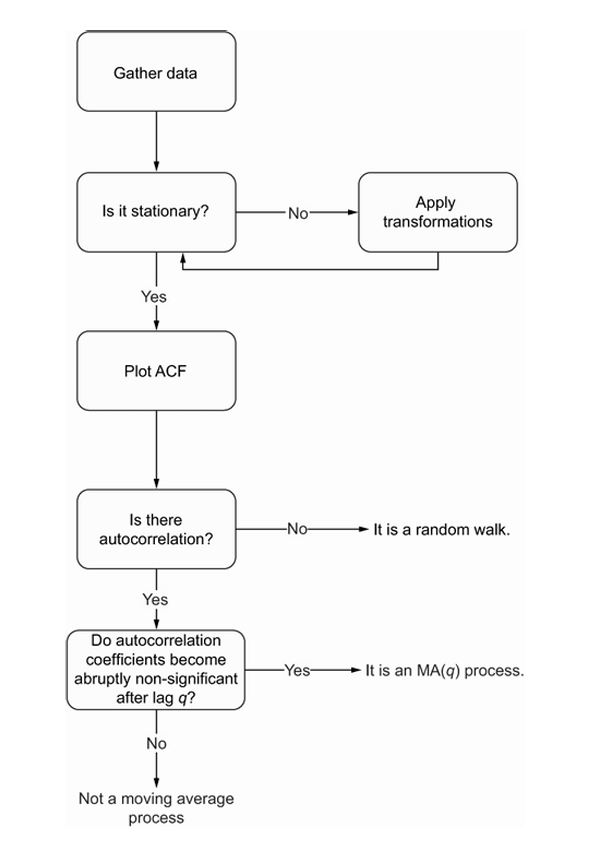

## **---coading process---**

In [60]:
# importing libraries and prerequisite
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.tsa.stattools as sts
import statsmodels.graphics.tsaplots as sgt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

### Gathering data

In [61]:
# Gathering data
df = pd.read_csv('widget_sales.csv')
df.head()

,widget_sales
0,50.496714
1,50.805493
2,51.477758
3,53.542228
4,54.873108


### plotting the graph

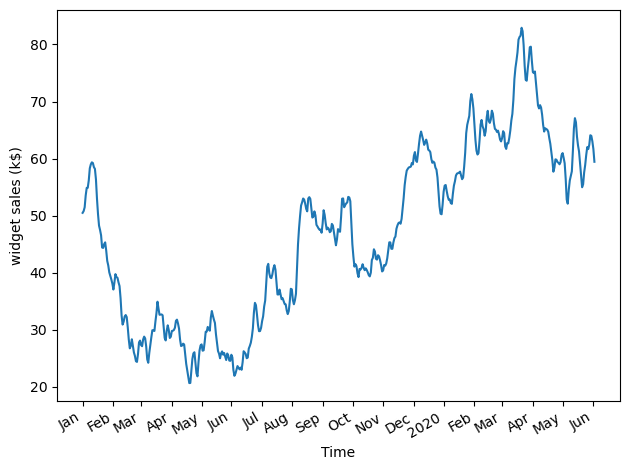

In [62]:
fig, ax=plt.subplots()
ax.plot(df['widget_sales'])
ax.set_xlabel('Time')
ax.set_ylabel('widget sales (k$)')
plt.xticks( 
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498],  
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct','Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])
fig.autofmt_xdate()                                               
plt.tight_layout() 

### checking stationarity

In [63]:
sts.adfuller(df['widget_sales'])

(np.float64(-1.5121662069358976),
 np.float64(0.527484535227264),
 3,
 496,
 {'1%': np.float64(-3.4436029548776395),
  '5%': np.float64(-2.867384756137026),
  '10%': np.float64(-2.5698830308597813)},
 np.float64(1354.8017397952053))

### **The p-value is > 0.05 and test statistic > table value so our data is not stationary**

### APPLYING TRANSFORMATION

In [64]:
widget_sales_diff=np.diff(df['widget_sales'],n=1)

### Again plotting the graph

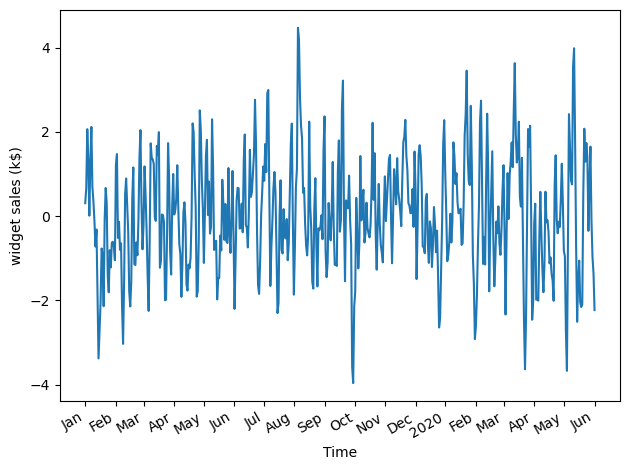

In [65]:
fig, ax=plt.subplots()
ax.plot(widget_sales_diff)
ax.set_xlabel('Time')
ax.set_ylabel('widget sales (k$)')
plt.xticks( 
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409,439, 468, 498],  
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])
fig.autofmt_xdate()                                               
plt.tight_layout()  

### Again checking Stationarity

In [66]:
sts.adfuller(widget_sales_diff)

(np.float64(-10.576657780341957),
 np.float64(7.076922818587346e-19),
 2,
 496,
 {'1%': np.float64(-3.4436029548776395),
  '5%': np.float64(-2.867384756137026),
  '10%': np.float64(-2.5698830308597813)},
 np.float64(1350.640860630276))

### The p-value < 0.05 and test statistic < table value so our data is stationary

### **Plotting ACF to check the correlation**

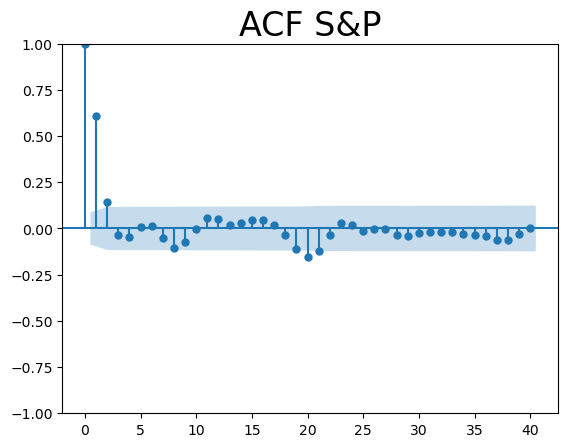

In [67]:
sgt.plot_acf(widget_sales_diff, lags = 40,)
plt.title("ACF S&P",size=24)
plt.show()

### **ACF plot of the differenced series. Notice how the coefficients are significant up until lag 2, and then they fall abruptly into the non significance zone (shaded area) of the plot. There are some significant coefficients around lag 20, but this is likely due to chance, since they are non-significant between lags 3 and 20 and after lag 20.**

In [68]:
# we will split our data into 2 parts 90% contains in training and 10% contain in testing
df_diff=pd.DataFrame({'widget_sales_diff':widget_sales_diff})
train=df_diff[:int(0.9*len(df_diff))]
test=df_diff[int(0.9*len(df_diff)):]
print(len(train))
print(len(test))

449
50


### **Visualizing the original and differenced series**

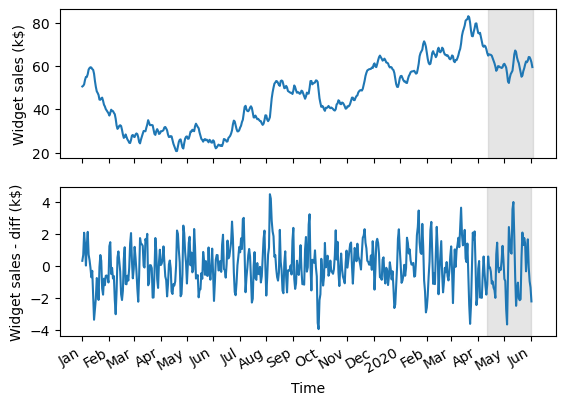

In [69]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)    
ax1.plot(df['widget_sales']) 
ax1.set_xlabel('Time') 
ax1.set_ylabel('Widget sales (k$)') 
ax1.axvspan(450, 500, color='#808080', alpha=0.2) 
ax2.plot(df_diff['widget_sales_diff']) 
ax2.set_xlabel('Time') 
ax2.set_ylabel('Widget sales - diff (k$)') 
ax2.axvspan(449, 498, color='#808080', alpha=0.2) 
plt.xticks( 
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 
498],  
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 
'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun']) 
fig.autofmt_xdate() 

## ***Forecasting period for the original and differenced series.Remember that our differenced series has one less data point than in its original state.***

## **NOTE-->** When using an MA(q) model, forecasting beyond q steps into the future will simply return the mean, because there are no error terms to estimate beyond q steps. We can use rolling forecasts to predict up to q steps at a time in order avoid predicting only the mean of the series.

We will compare our fitted MA(2) model to two baselines: the historical
mean and the last value. That way, we can make sure that an MA(2) model
will yield better predictions than naive forecasts, which should be the case,
since we know the stationary process is an MA(2) process.

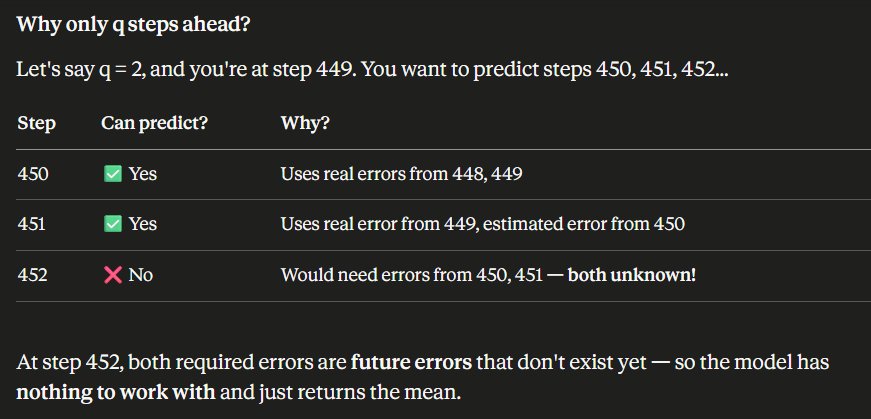
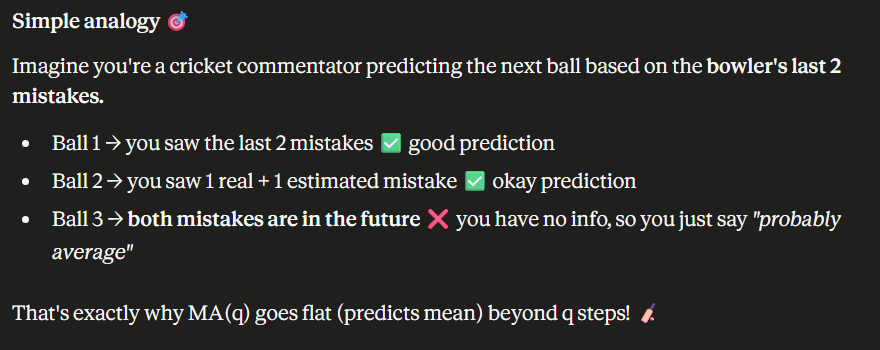
### **MA model borrows information from past errors. Once you go beyond q steps, there are no past errors to borrow from — so it gives up and just predicts the mean.**

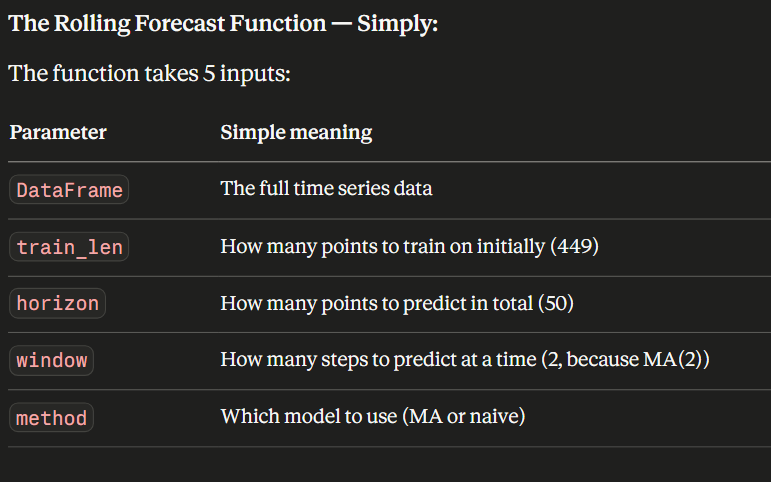
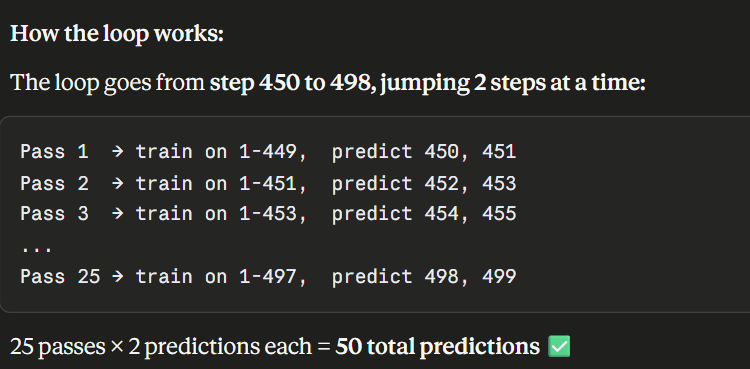
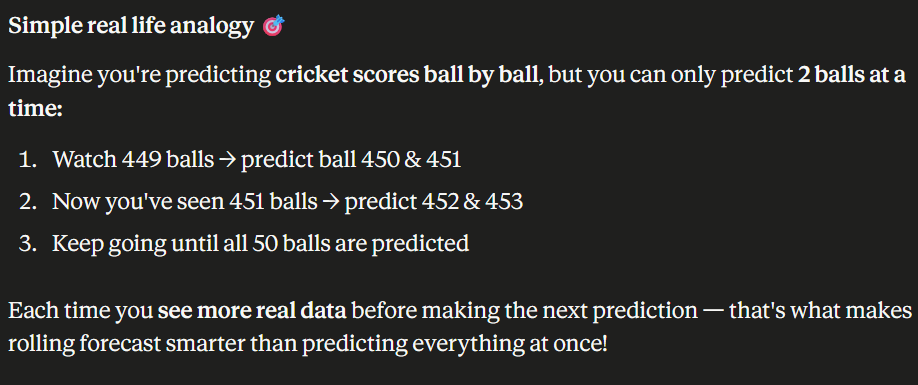

### ***The function is just a loop that keeps retraining the MA(2) model on slightly more data each time, predicting 2 steps ahead per pass, until all 50 predictions are done.***

# ***---A function for rolling forecasts on a horizon---***

In [70]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def rolling_forecast(df: pd.DataFrame, train_len: int,horizon: int,window: int,method: str) -> list:
    total_len=train_len + horizon

    if method == 'mean': #(Naive Mean Forecast)
        pred_mean = []

        for i in range(train_len, total_len, window): # Loop from 450 → 500, jumping 2 at a time
            mean = np.mean(df[:i].values) #  calculate the mean of all data seen so far
            pred_mean.extend(mean for _ in range(window)) # Add that mean twice (window=2) to the list
  
        return pred_mean

    elif method == 'last': # Naive Last Value Forecast
        pred_last_value = [] 
         
        for i in range(train_len, total_len, window): 
            last_value = df[:i].iloc[-1].values[0] # Each pass → grab the very last value seen so far
            pred_last_value.extend(last_value for _ in range(window)) # Repeat that value twice and add to list
        return pred_last_value


    elif method == 'MA': # The actual MA(2) model
        pred_MA = [] 
         
        for i in range(train_len, total_len, window): 
            model = SARIMAX(df[:i], order=(0,0,2)) # Train the model on data seen so far (df[:i]) , order=(0,0,2) means:0 → no autoregressive terms, 0 → no differencing, 2 → MA(2) model 
            res = model.fit(disp=False) #Actually trains/fits the model , disp=False just means "don't print training logs"
            predictions = res.get_prediction(0, i + window - 1) # Get predictions from step 0 all the way to i+1, e.g. on first pass: predict from 0 to 450
            oos_pred = predictions.predicted_mean.iloc[-window:] # From all those predictions, grab only the last 2 (the out-of-sample ones), These are the actual future forecasts we care about
            pred_MA.extend(oos_pred) # Add those 2 predictions to our results list
        return pred_MA

### ***We just built the rolling_forecast function earlier. Now we're actually using it to generate predictions from 3 methods and storing them neatly in a table.***

In [71]:
pred_df = test.copy() 
TRAIN_LEN = len(train) 
HORIZON = len(test) 
WINDOW = 2 
pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean') 
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW,'last') 
pred_MA = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'MA') 
pred_df['pred_mean'] = pred_mean 
pred_df['pred_last_value'] = pred_last_value 
pred_df['pred_MA'] = pred_MA 
pred_df.head()

,widget_sales_diff,pred_mean,pred_last_value,pred_MA
449,-1.170131,0.034319,-1.803658,-1.078833
450,0.580967,0.034319,-1.803658,-0.273309
451,-0.144902,0.032861,0.580967,0.781223
452,-0.096564,0.032861,0.580967,0.234969
453,-0.372334,0.032183,-0.096564,0.168994


## **Now we can visualize our predictions against the observed values.**

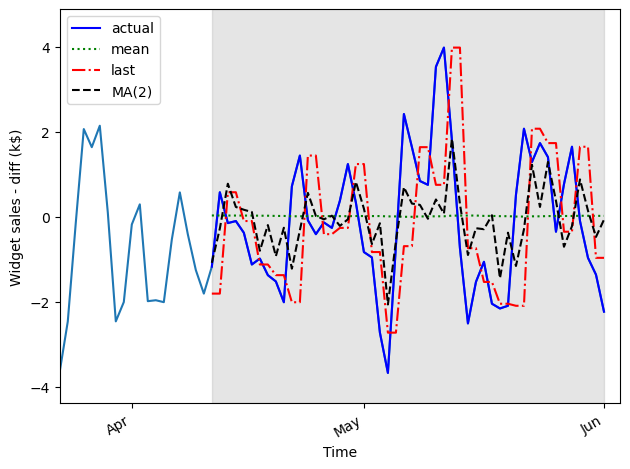

In [72]:
fig, ax = plt.subplots()

ax.plot(df_diff['widget_sales_diff'])
ax.plot(pred_df['widget_sales_diff'], 'b-', label='actual')
ax.plot(pred_df['pred_mean'], 'g:', label='mean')
ax.plot(pred_df['pred_last_value'], 'r-.', label='last')
ax.plot(pred_df['pred_MA'], 'k--', label='MA(2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Widget sales - diff (k$)')

ax.axvspan(449, 498, color='#808080', alpha=0.2)

ax.set_xlim(430, 500)

plt.xticks(
    [439, 468, 498], 
    ['Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

## *Forecasts of the differenced volume of widget sales. In a professional setting, it does not make sense to report differenced predictions. Therefore, we will undo the transformation later on.*

## ***---The next step is to measure the performance of our models. To do so, we will calculate the mean squared error (MSE).---***

In [74]:
from sklearn.metrics import mean_squared_error 
mse_mean = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_mean']) 
mse_last = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_last_value']) 
mse_MA = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_MA']) 
print(mse_mean, mse_last, mse_MA)

2.5606299456880537 3.2494260812249225 1.9481714498036409


## **As we can see the MA error is low as compared to the historical mean, last value_methods so MA(2) model is better predictor.**

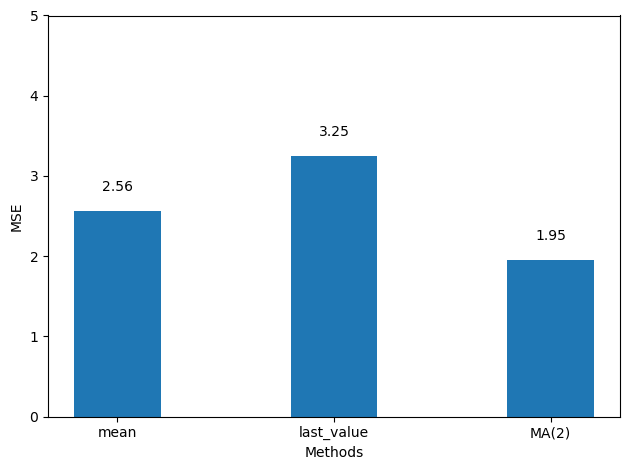

In [75]:
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'MA(2)']
y = [mse_mean, mse_last, mse_MA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 5)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.25, s=str(round(value, 2)), ha='center')

plt.tight_layout()

##  MSE for each forecasting method on the differenced volume of widget sales. Here the MA(2) model is the champion, since its MSE is the lowest.

Now that we have our champion model on the stationary series, we need to
inverse-transform our predictions to bring them back to the original scale of
the untransformed dataset

In [79]:
df['pred_widget_sales'] = pd.Series() 
df['pred_widget_sales'][450:] = df['widget_sales'].iloc[450] + pred_df['pred_MA'].cumsum()
df.tail()

,widget_sales,pred_widget_sales
495,64.087371,60.335201
496,63.992081,61.218392
497,63.029894,61.365771
498,61.671797,60.895973
499,59.443839,60.832373


### ***Let’s visualize our untransformed predictions against the recorded data.***

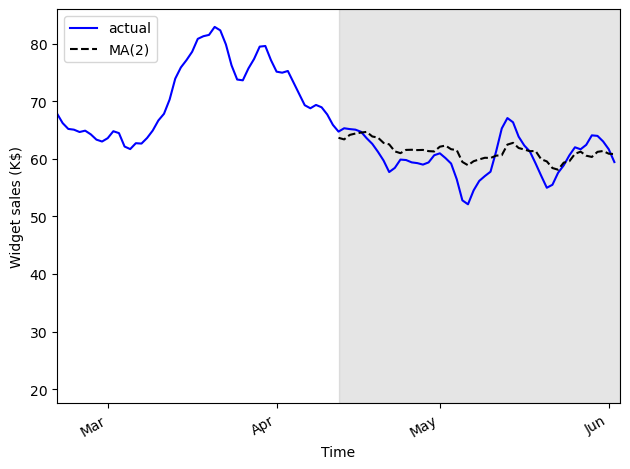

In [80]:
fig, ax = plt.subplots()

ax.plot(df['widget_sales'], 'b-', label='actual')
ax.plot(df['pred_widget_sales'], 'k--', label='MA(2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (K$)')

ax.axvspan(450, 500, color='#808080', alpha=0.2)

ax.set_xlim(400, 500)

plt.xticks(
    [409, 439, 468, 498], 
    ['Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

## **Inverse-transformed MA(2) forecasts***

### The final step is to report the MSE on the original dataset.

In [81]:
from sklearn.metrics import mean_absolute_error

mae_MA_undiff = mean_absolute_error(df['widget_sales'].iloc[450:], df['pred_widget_sales'].iloc[450:])

print(mae_MA_undiff)

2.324470924541618


This prints out an MAE of 2.32. Therefore, our predictions are, on average,
off by $2,320, either above or below the actual value. Remember that our
data has units of thousands of dollars, so we multiply the MAE by 1,000 to
express the average absolute difference.


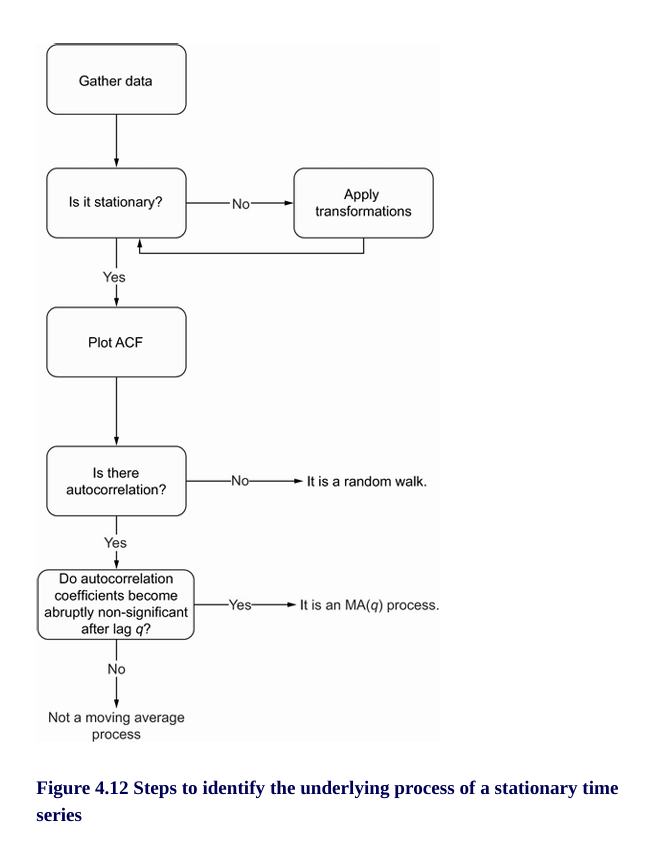